In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
PROCESSED_DATA_PATH = "../data/processed/"

df_daily_clean = pd.read_csv(PROCESSED_DATA_PATH + "sales_daily_clean.csv")
df_hourly_clean = pd.read_csv(PROCESSED_DATA_PATH + "sales_hourly_clean.csv")
df_monthly_clean = pd.read_csv(PROCESSED_DATA_PATH+ "sales_monthly_clean.csv")
df_weekly_clean = pd.read_csv(PROCESSED_DATA_PATH + "sales_weekly_clean.csv")

In [43]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,5)

In [44]:
#CSV is a lossy format — it doesn't preserve dtypes, index, or metadata. 
#Every time you reload from CSV you must re-apply type conversions. 
#This is why production pipelines use formats like Parquet instead — 
#Parquet preserves schema and dtypes automatically.


In [45]:
df_daily_clean['datum'] = pd.to_datetime(df_daily_clean['datum'])
df_hourly_clean['datum'] = pd.to_datetime(df_hourly_clean['datum'])
df_monthly_clean['datum'] = pd.to_datetime(df_monthly_clean['datum'])
df_weekly_clean['datum'] = pd.to_datetime(df_weekly_clean['datum'])

Sum:
m01ab    10499.440
m01ae     8156.000
n02ba     8051.459
n02be    62477.945
n05b     18348.300
n05c      1249.000
r03      11737.250
r06       6066.380
dtype: float64
Sorted results are:
n02be    62477.945
n05b     18348.300
r03      11737.250
m01ab    10499.440
m01ae     8156.000
n02ba     8051.459
r06       6066.380
n05c      1249.000
dtype: float64


Text(0, 0.5, 'SUM')

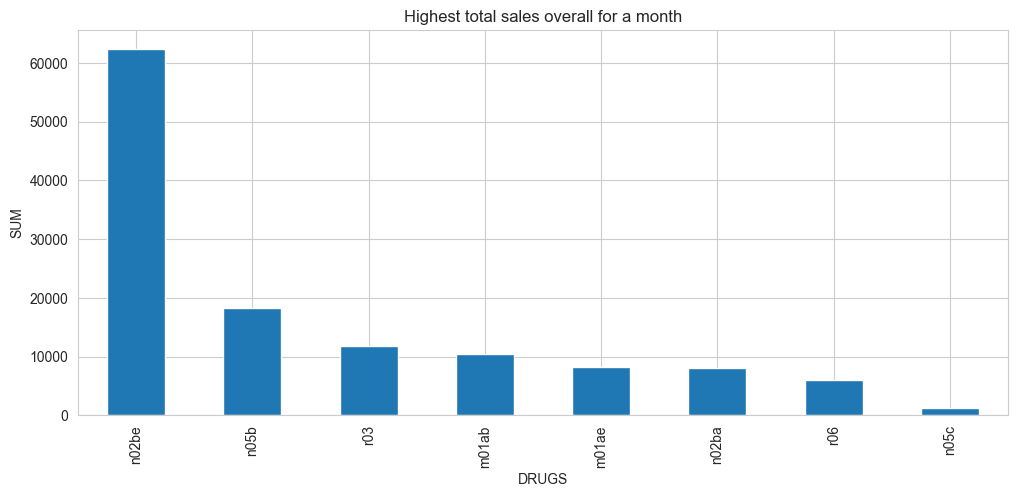

In [46]:
#CHECKS THE HIGHEST TOTAL SALES OVERALL

drug_cols = ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06']
df_sum = df_monthly_clean[drug_cols].sum()
print(f"Sum:\n{df_sum}")

sorted_df = df_sum.sort_values(ascending = False)

print(f"Sorted results are:\n{sorted_df}")
sorted_df.plot(kind='bar')
plt.title('Highest total sales overall for a month')
plt.xlabel('DRUGS')
plt.ylabel('SUM')


Updated data frame with total sales:
            total_sales
datum                  
2014-01-31     1821.110
2014-02-28     1974.470
2014-03-31     1606.720
2014-04-30     1429.675
2014-05-31     1506.303


(array([528, 540, 552, 564, 576, 588]),
 [Text(528, 0, '2014'),
  Text(540, 0, '2015'),
  Text(552, 0, '2016'),
  Text(564, 0, '2017'),
  Text(576, 0, '2018'),
  Text(588, 0, '2019')])

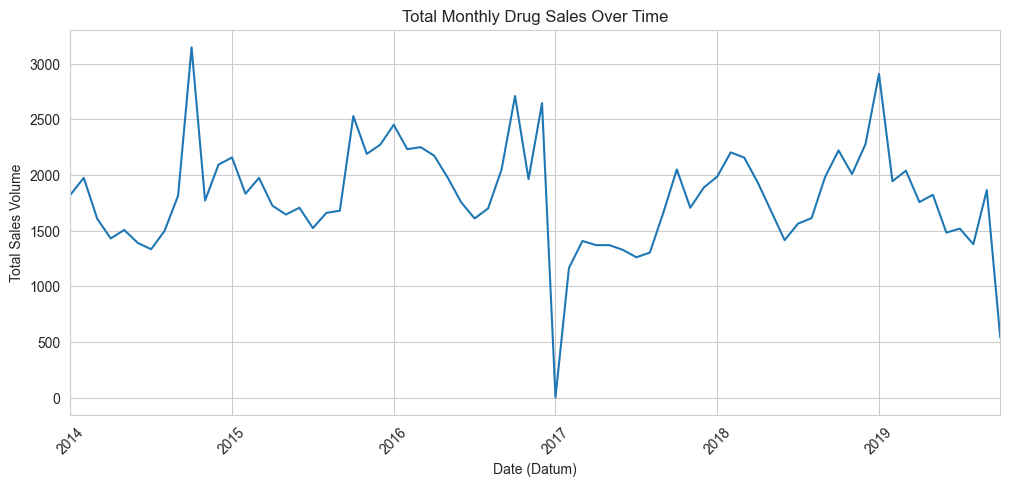

In [47]:
#if 'datum' in df_monthly_clean.columns:
df_monthly_clean.set_index('datum', inplace=True)

drug_cols = ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06']
df_monthly_clean['total_sales'] = df_monthly_clean[drug_cols].sum(axis=1)

print("Updated data frame with total sales:")
print(df_monthly_clean[['total_sales']].head())

df_monthly_clean['total_sales'].plot(kind = 'line')

plt.title('Total Monthly Drug Sales Over Time')
plt.xlabel('Date (Datum)')
plt.ylabel('Total Sales Volume')

plt.xticks(rotation=45)

In [48]:
#observing sudden drop in early year of 2017

suspicious  = df_monthly_clean[df_monthly_clean.index.year == 2017]

print(suspicious[drug_cols])

             m01ab    m01ae   n02ba     n02be   n05b  n05c    r03     r06
datum                                                                    
2017-01-31    0.00    0.000    0.00     0.000    1.0   0.0    0.0    0.00
2017-02-28  139.69  103.517   97.00   526.350  144.0   7.0  117.0   30.60
2017-03-31  162.85  111.055  107.35   612.500  165.0   9.0  139.0  100.10
2017-04-30  155.61  101.215  100.50   540.200  132.0   9.0  209.0  122.40
2017-05-31  143.66  118.125   98.95   547.940  148.0  23.0  128.0  161.81
2017-06-30  122.33  103.006  119.60   496.100  163.0   8.0  163.0  151.90
2017-07-31  159.67  116.206   75.20   479.350  219.0  15.0  115.0   81.10
2017-08-31  170.15  112.470   84.40   549.300  239.0  12.0   75.0   60.10
2017-09-30  138.33  118.711   88.15   863.750  223.0  23.0  139.0   66.90
2017-10-31  137.64   88.737  100.40  1184.350  226.0  15.0  247.0   51.00
2017-11-30  163.85  119.780  104.45   867.899  192.0  15.0  196.0   46.60
2017-12-31  160.01  121.663  115.15  1

In [49]:
#identifying January 2017 rows and replacing with NaN

condition = ((df_monthly_clean.index.year == 2017) & (df_monthly_clean.index.month == 1))
df_monthly_clean.loc[condition, drug_cols] = np.nan

In [50]:
df_monthly_clean[drug_cols] = df_monthly_clean[drug_cols].interpolate(method = 'time')

In [51]:
suspicious_after = df_monthly_clean[(df_monthly_clean.index.year == 2017)]

print(suspicious_after[drug_cols])

                 m01ab       m01ae   n02ba        n02be        n05b  \
datum                                                                 
2017-01-31  153.751695  118.484661  113.80  1047.427627  197.627119   
2017-02-28  139.690000  103.517000   97.00   526.350000  144.000000   
2017-03-31  162.850000  111.055000  107.35   612.500000  165.000000   
2017-04-30  155.610000  101.215000  100.50   540.200000  132.000000   
2017-05-31  143.660000  118.125000   98.95   547.940000  148.000000   
2017-06-30  122.330000  103.006000  119.60   496.100000  163.000000   
2017-07-31  159.670000  116.206000   75.20   479.350000  219.000000   
2017-08-31  170.150000  112.470000   84.40   549.300000  239.000000   
2017-09-30  138.330000  118.711000   88.15   863.750000  223.000000   
2017-10-31  137.640000   88.737000  100.40  1184.350000  226.000000   
2017-11-30  163.850000  119.780000  104.45   867.899000  192.000000   
2017-12-31  160.010000  121.663000  115.15  1007.180000  226.000000   

     

In [52]:
print(df_monthly_clean[(df_monthly_clean.index.year == 2016) & (df_monthly_clean.index.month == 12)][drug_cols])

             m01ab    m01ae  n02ba     n02be   n05b  n05c    r03   r06
datum                                                                 
2016-12-31  169.32  135.056  132.4  1624.335  257.0  18.0  275.0  34.9


In [53]:
filepath = "../data/processed/sales_monthly_imputed.csv"
df_monthly_clean.to_csv(filepath, index=True)
print(f"Saved imputed data to: {filepath}")

Saved imputed data to: ../data/processed/sales_monthly_imputed.csv


In [54]:
print(df_monthly_clean['total_sales'])

datum
2014-01-31    1821.110
2014-02-28    1974.470
2014-03-31    1606.720
2014-04-30    1429.675
2014-05-31    1506.303
                ...   
2019-06-30    1482.407
2019-07-31    1517.941
2019-08-31    1377.779
2019-09-30    1864.387
2019-10-31     538.600
Name: total_sales, Length: 70, dtype: float64


Highest Avg sales are : month
1     1887.466500
2     1891.834000
3     1905.600833
4     1731.390500
5     1665.779333
6     1512.456000
7     1467.740833
8     1525.129667
9     1841.740000
10    2199.447500
11    1927.460000
12    2235.392600
Name: total_sales, dtype: float64


Text(0, 0.5, 'Total sales')

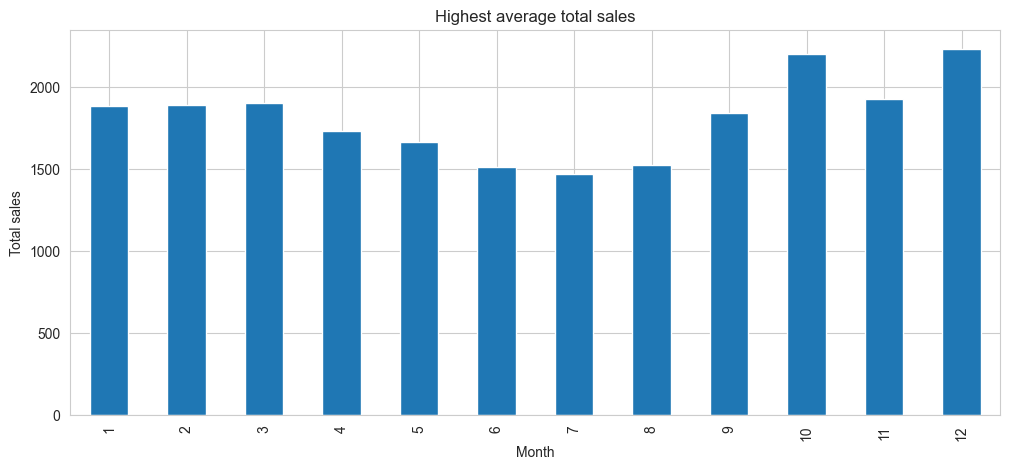

In [55]:
#GroupBy

highest_average_sales = df_monthly_clean.groupby('month')['total_sales'].mean()

print(f"Highest Avg sales are : {highest_average_sales}")

highest_average_sales.plot(kind = 'bar')
plt.title('Highest average total sales')
plt.xlabel('Month')
plt.ylabel('Total sales')

Highest Avg sales are : month
1     1887.466500
2     1891.834000
3     1905.600833
4     1731.390500
5     1665.779333
6     1512.456000
7     1467.740833
8     1525.129667
9     1841.740000
10    2199.447500
11    1927.460000
12    2235.392600
Name: total_sales, dtype: float64


Text(0, 0.5, 'Total sales')

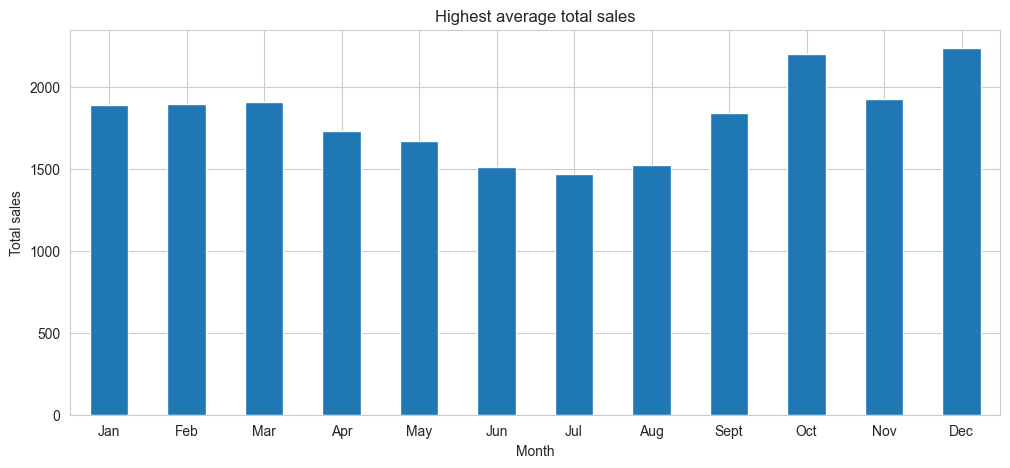

In [56]:
#GroupBy

highest_average_sales = df_monthly_clean.groupby('month')['total_sales'].mean()

print(f"Highest Avg sales are : {highest_average_sales}")

highest_average_sales.plot(kind = 'bar')
plt.title('Highest average total sales')

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
plt.xticks(range(12), month_names)
plt.xticks(rotation='horizontal')

plt.xlabel('Month')
plt.ylabel('Total sales')


In [57]:
#EDA for Day of week pattern

In [58]:
#daily data

print(df_daily_clean[['datum','day_of_week'] + drug_cols].head(10))

       datum  day_of_week  m01ab  m01ae  n02ba  n02be  n05b  n05c   r03  r06
0 2014-01-02            3   0.00   3.67    3.4  32.40   7.0   0.0   0.0  2.0
1 2014-01-03            4   8.00   4.00    4.4  50.60  16.0   0.0  20.0  4.0
2 2014-01-04            5   2.00   1.00    6.5  61.85  10.0   0.0   9.0  1.0
3 2014-01-05            6   4.00   3.00    7.0  41.10   8.0   0.0   3.0  0.0
4 2014-01-06            0   5.00   1.00    4.5  21.70  16.0   2.0   6.0  2.0
5 2014-01-07            1   0.00   0.00    0.0   0.00   0.0   0.0   0.0  0.0
6 2014-01-08            2   5.33   3.00   10.5  26.40  19.0   1.0  10.0  0.0
7 2014-01-09            3   7.00   1.68    8.0  25.00  16.0   0.0   3.0  2.0
8 2014-01-10            4   5.00   2.00    2.0  53.30  15.0   2.0   0.0  2.0
9 2014-01-11            5   5.00   4.34   10.4  52.30  14.0   0.0   1.0  0.2


In [59]:
df_daily_clean['total_sales'] = df_daily_clean[drug_cols].sum(axis=1)

In [60]:
groups = df_daily_clean.groupby('day_of_week')['total_sales']
for name, group in groups:
    print(f"\nDay {name} — first 3 values:")
    print(group.head(3).values)
    print(f"Mean: {group.mean():.2f}")


Day 0 — first 3 values:
[58.2  90.2  59.54]
Mean: 60.61

Day 1 — first 3 values:
[ 0.   62.33 69.34]
Mean: 60.02

Day 2 — first 3 values:
[75.23 58.04 52.1 ]
Mean: 59.24

Day 3 — first 3 values:
[48.47 62.68 65.6 ]
Mean: 57.18

Day 4 — first 3 values:
[107.    81.3   58.38]
Mean: 60.25

Day 5 — first 3 values:
[91.35 87.24 83.33]
Mean: 65.67

Day 6 — first 3 values:
[66.1  27.16 32.43]
Mean: 61.13


Highest Avg day of week sales are : day_of_week
0    60.607364
1    60.017432
2    59.238425
3    57.184018
4    60.247480
5    65.673071
6    61.134343
Name: total_sales, dtype: float64


(50.0, 70.0)

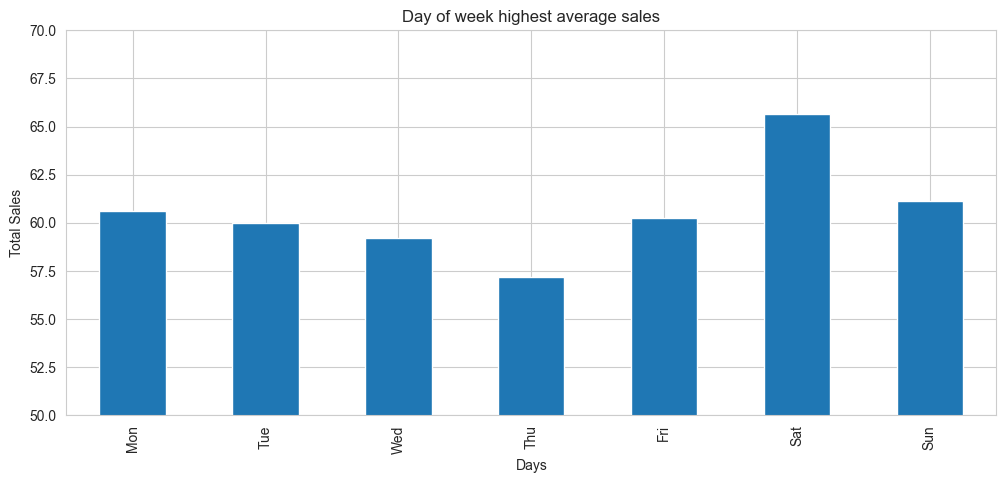

In [61]:
#which day of the week has highest average sales

drug_cols = ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06']
df_daily_clean['total_sales'] = df_daily_clean[drug_cols].sum(axis=1)

highest_average_day_of_week_sales = df_daily_clean.groupby('day_of_week')['total_sales'].mean()

print(f"Highest Avg day of week sales are : {highest_average_day_of_week_sales}")

highest_average_day_of_week_sales.plot(kind = 'bar')
plt.title('Day of week highest average sales')

day_names = ['Mon','Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.xticks(range(7), day_names)

plt.xlabel('Days')
plt.ylabel('Total Sales')

plt.ylim(50, 70)

Hourly_average_sales are: hour
0     0.000000
1     0.000000
2     0.000000
3     0.000000
4     0.000000
5     0.000000
6     0.000000
7     0.272004
8     2.868352
9     3.843552
10    4.554328
11    5.096845
12    5.007699
13    4.545759
14    4.169361
15    3.887425
16    3.728370
17    3.919423
18    4.782325
19    5.375953
20    5.325920
21    3.137042
22    0.076209
23    0.000277
Name: total_sales, dtype: float64


(0.0, 23.0)

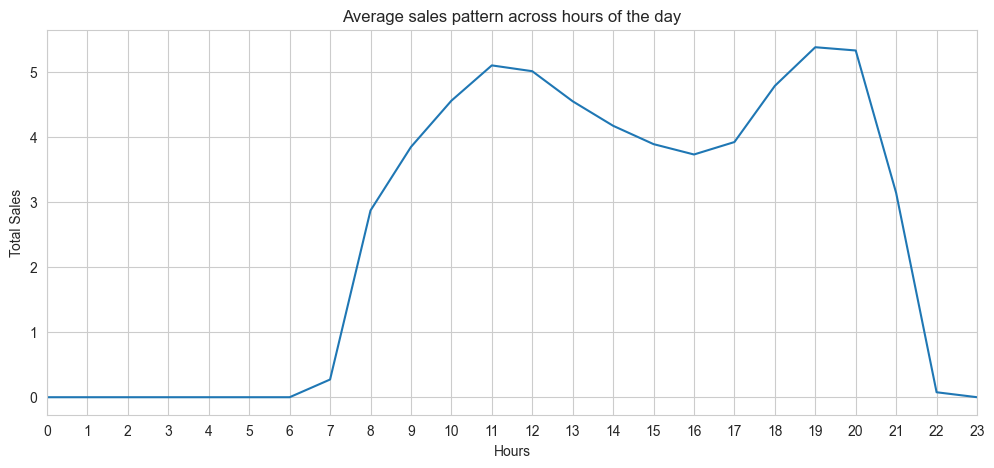

In [62]:
#average sales across hours of the day

drug_cols = ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06']
df_hourly_clean['total_sales'] = df_hourly_clean[drug_cols].sum(axis=1)

hourly_average_sales = df_hourly_clean.groupby('hour')['total_sales'].mean()

print(f"Hourly_average_sales are: {hourly_average_sales}")

hourly_average_sales.plot(kind = 'line')
plt.title('Average sales pattern across hours of the day')

hrs = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]
plt.xticks(range(24), hrs)
           
plt.xlabel('Hours')
plt.ylabel('Total Sales')

plt.xlim(0,23)

          m01ab     m01ae     n02ba     n02be      n05b      n05c       r03  \
m01ab  1.000000  0.433096  0.214708  0.306032 -0.031703 -0.085994  0.215884   
m01ae  0.433096  1.000000  0.429901  0.658769  0.261073  0.040067  0.381249   
n02ba  0.214708  0.429901  1.000000  0.474466  0.392640  0.184956 -0.077485   
n02be  0.306032  0.658769  0.474466  1.000000  0.282872  0.136254  0.573767   
n05b  -0.031703  0.261073  0.392640  0.282872  1.000000  0.545063  0.032714   
n05c  -0.085994  0.040067  0.184956  0.136254  0.545063  1.000000  0.161741   
r03    0.215884  0.381249 -0.077485  0.573767  0.032714  0.161741  1.000000   
r06    0.217125 -0.103204 -0.152623 -0.393952 -0.139691 -0.064198 -0.064437   

            r06  
m01ab  0.217125  
m01ae -0.103204  
n02ba -0.152623  
n02be -0.393952  
n05b  -0.139691  
n05c  -0.064198  
r03   -0.064437  
r06    1.000000  


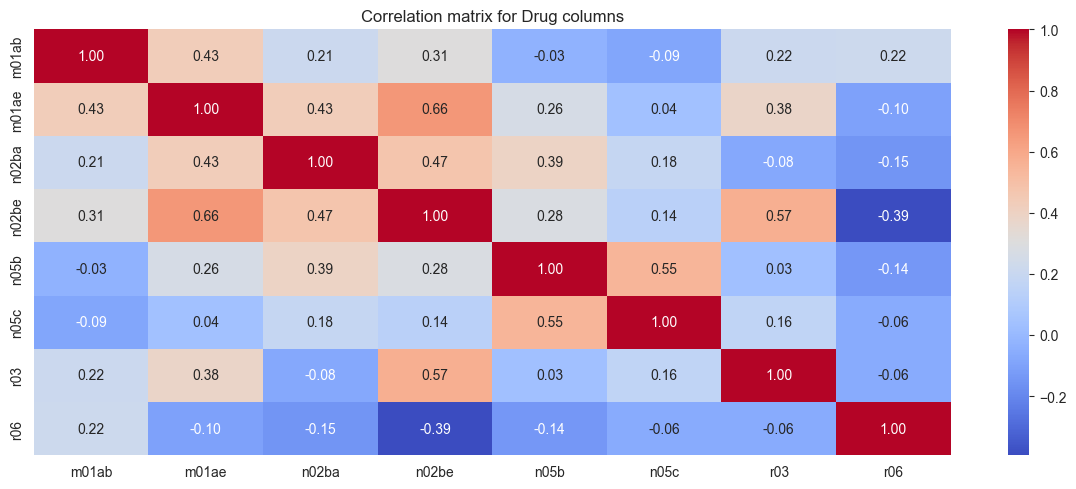

In [63]:
#CORRELATION

corr_matrix = df_monthly_clean[drug_cols].corr()

print(corr_matrix)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation matrix for Drug columns')
plt.tight_layout()